# 15 - Sampling f̃ = f_acc/(1 + f_acc) instead of f_acc

f_acc is the parent density relative to the stable CDM. The accDM *share* of the dark matter is

$$\tilde f = \frac{f_{\rm acc}}{1 + f_{\rm acc}} = \frac{\omega_{\rm acc}}{\omega_{\rm cdm} + \omega_{\rm acc}},$$

exact before the transition and, today, up to the daughters' kinetic energy. `f_tilde` can replace
`f_acc` as input (not both); CLASS sets f_acc = f̃/(1 − f̃), so f̃ ∈ [0, 1). With `omega_dm_tot`
(notebook 13) the split becomes linear: ω_cdm = ω_dm,tot(1 − f̃), parent = ω_dm,tot f̃.

**Result.**
- `f_tilde` is a pure change of input: every f̃ run is bit-identical to the f_acc run given f̃/(1 − f̃),
  and bad inputs stop with a clear message (section 1). Where f̃/(1 − f̃) lands one ulp away from the
  nominal f_acc, the spectra move by up to ~10⁻⁴ of their peak; a 10⁻¹² nudge of f_acc does the same, so
  this is CLASS's own repeatability floor.
- f̃ is the parent share before the transition to round-off, and the accDM share today to 2.5% at
  10¹¹ GeV (f̃ = 0.1) and better than 2·10⁻⁵ from 10¹⁴ GeV up (section 2).
- CLASS runs to f̃ = 0.9999 (f_acc ≈ 10⁴) at the same cost; beyond f_acc ≈ 10 the observables saturate,
  and a flat f̃ prior puts 9% of its mass there (section 3). The momentum grid must be refined at large
  f̃: notebooks 16–17.
- σ8 is much closer to linear in f̃ than in f_acc (largest straight-line residual 8–17% of the total
  change, against 42–51%), which is easier for an emulator (section 4).
- The prior is the physical difference: flat f̃ gives half its weight to f_acc < 1, flat f_acc on [0, 10]
  only 10%. For the current chains (flat f̃) the other priors move the 95% f̃ limit by < 2% up to
  10¹⁴ GeV and by up to 27% at 10^15.7 GeV (0.225 → 0.285 for flat f_acc) (section 5).
- Every current posterior hugs f_acc ≈ 0, where a flat-f̃ Latin hypercube puts 7–10× more
  first-iteration training points than a flat-f_acc one (section 6).

CLASS runs use the settings of the `connect/new` chains and their 10¹⁴ GeV best fit of 2026-10-05
(fixed values, see `accdm_nb`); cached in `15_cache.pkl`. Chain sections use the current chains in
`chains/fixed_masses/k12.1a0.133`.

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from scipy.stats import qmc

from accdm_nb import (CONNECT_NEW, LCDM_NEW14_OCT05, OMEGA_DM_TOT_OCT05, RunCache, chains_dir, load_chain,
                      mass_dirs, ok, status, show, wmean, wquantile, ess, plot_style)

plot_style()

LCDM, OMEGA_DM_TOT = LCDM_NEW14_OCT05, OMEGA_DM_TOT_OCT05
SPECTRA = ('tt', 'ee', 'te', 'pp')


def summary(cosmo):
    out = {'omega_cdm': cosmo.Omega0_cdm()*cosmo.h()**2, 'sigma8': cosmo.sigma8(), '100theta_s': cosmo.theta_s_100()}
    if 'lCl' in cosmo.pars['output']:
        cl = cosmo.lensed_cl(2500)
        out.update({s: np.asarray(cl[s])[2:] for s in SPECTRA})
    return out


def shares(cosmo):
    bg = cosmo.get_background()
    cdm, par, dau = bg['(.)rho_cdm'], bg['(.)rho_acc_cdm'], bg['(.)rho_ncdm[1]']
    i = np.argmin(np.abs(np.log(1 + bg['z']) - np.log(1 + 1e6)))
    return {'early': par[i]/(cdm[i] + par[i]), 'today': (par[-1] + dau[-1])/(cdm[-1] + par[-1] + dau[-1]),
            'w today': bg['(.)p_ncdm[1]'][-1]/dau[-1]}


cache = RunCache('15_cache.pkl', extract=summary, workers=8)
cache_bg = RunCache('15_cache.pkl', extract=shares, level=['background'], workers=8)
common = {**CONNECT_NEW, **LCDM, 'omega_dm_tot': OMEGA_DM_TOT}
SAMPLES = {float(d.name): load_chain(d) for d in mass_dirs(chains_dir('k12.1a0.133'))}


def max_dcl(a, b):
    return max(np.max(np.abs(a[s] - b[s]))/np.max(np.abs(b[s])) for s in SPECTRA)

## 1. Same model, four inputs

At m = 10¹⁶ GeV, each f_acc is run from f̃ and from f_acc, with ω_dm,tot or with ω_cdm. CLASS turns f̃
back into f_acc = f̃/(1 − f̃), which can differ from the nominal f_acc in the last bit, so the f̃ runs are
compared with f_acc runs given that round-tripped value: they must agree exactly. f_acc = 0 checks the
empty-daughter case.

In [2]:
F_TEST = [0.0, 0.3, 1.0, 5.0, 10.0]
base = {**common, 'm_acc_in_GeV': 1e16}
base.pop('omega_dm_tot')


def round_trip(f):
    ft = f/(1 + f)
    return ft/(1 - ft)


pairs = {}
for f in F_TEST:
    ft, frt = f/(1 + f), round_trip(f)
    pairs[(f, 'omega_dm_tot')] = ({**base, 'omega_dm_tot': OMEGA_DM_TOT, 'f_tilde': ft},
                                  {**base, 'omega_dm_tot': OMEGA_DM_TOT, 'f_acc': frt})
    pairs[(f, 'omega_cdm')] = ({**base, 'omega_cdm': OMEGA_DM_TOT/(1 + frt), 'f_tilde': ft},
                               {**base, 'omega_cdm': OMEGA_DM_TOT/(1 + frt), 'f_acc': frt})
out = cache.many([p for pair in pairs.values() for p in pair])
rows = []
for (f, second), a, b in zip(pairs, out[::2], out[1::2]):
    assert ok(a) and ok(b), (status(a), status(b))
    rows.append({'f_acc': f, 'with': second, 'f_acc round trip − f_acc': round_trip(f) - f, 'sigma8': a['sigma8'],
                 'max |ΔC_l|': max_dcl(a, b), '|Δsigma8|': abs(a['sigma8'] - b['sigma8'])})
same = pd.DataFrame(rows).set_index(['f_acc', 'with'])
show(same, {'sigma8': '{:.5f}'}, default='{:.1e}')
assert (same[['max |ΔC_l|', '|Δsigma8|']] == 0).all().all()

20 new CLASS runs in 168 s


f_acc round trip − f_acc   sigma8 max |ΔC_l| |Δsigma8|
f_acc with                                                               
0.0   omega_dm_tot                  0.0e+00  0.80819    0.0e+00   0.0e+00
      omega_cdm                     0.0e+00  0.80819    0.0e+00   0.0e+00
0.3   omega_dm_tot                  0.0e+00  0.74426    0.0e+00   0.0e+00
      omega_cdm                     0.0e+00  0.74426    0.0e+00   0.0e+00
1.0   omega_dm_tot                  0.0e+00  0.67596    0.0e+00   0.0e+00
      omega_cdm                     0.0e+00  0.67596    0.0e+00   0.0e+00
5.0   omega_dm_tot                  1.8e-15  0.60248    0.0e+00   0.0e+00
      omega_cdm                     1.8e-15  0.60248    0.0e+00   0.0e+00
10.0  omega_dm_tot                 -3.6e-15  0.58772    0.0e+00   0.0e+00
      omega_cdm                    -3.6e-15  0.58772    0.0e+00   0.0e+00

### 1b. Rejected inputs

Background level is enough; these must stop at input with a message naming the problem.

In [3]:
BAD = {'f_acc and f_tilde': {'f_acc': 1.0, 'f_tilde': 0.5}, 'f_tilde = 1': {'f_tilde': 1.0},
       'f_tilde = 1.5': {'f_tilde': 1.5}, 'f_tilde = -0.1': {'f_tilde': -0.1},
       'f_tilde, omega_dm_tot and omega_cdm': {'f_tilde': 0.5, 'omega_cdm': 0.06},
       'f_tilde = 0.999999 (accepted)': {'f_tilde': 0.999999}}
for label, extra in BAD.items():
    r = cache_bg({**common, 'm_acc_in_GeV': 1e16, **extra})
    msg = r['error'].split(' is true; ')[-1] if 'error' in r else 'ACCEPTED'
    print('{:<38s} {}'.format(label, msg))
    assert (msg == 'ACCEPTED') == label.endswith('(accepted)')

1 new CLASS runs in 0 s
f_acc and f_tilde                      You can only enter one of 'f_acc' or 'f_tilde'.


1 new CLASS runs in 0 s
f_tilde = 1                            'f_tilde' must be in [0,1), got 1.


1 new CLASS runs in 0 s
f_tilde = 1.5                          'f_tilde' must be in [0,1), got 1.5.


1 new CLASS runs in 0 s
f_tilde = -0.1                         'f_tilde' must be in [0,1), got -0.1.


1 new CLASS runs in 0 s
f_tilde, omega_dm_tot and omega_cdm    You can only enter one of 'Omega_cdm', 'omega_cdm' or 'omega_dm_tot'.


1 new CLASS runs in 0 s
f_tilde = 0.999999 (accepted)          ACCEPTED


### 1c. Repeatability under last-bit changes of f_acc

f̃ vs nominal f_acc (one ulp apart for f_acc = 5, 10), and f_acc vs f_acc(1 + 10⁻¹²) with no f̃
involved: max |ΔC_ℓ| relative to the peak, per spectrum.

In [4]:
rows = []
for f in F_TEST[1:]:
    ref, eps = cache.many([{**common, 'm_acc_in_GeV': 1e16, 'f_acc': f},
                           {**common, 'm_acc_in_GeV': 1e16, 'f_acc': f*(1 + 1e-12)}], verbose=False)
    ft_run = cache(pairs[(f, 'omega_dm_tot')][0])
    for label, a in (('f_tilde vs nominal f_acc', ft_run), ('f_acc(1 + 1e-12) vs f_acc', eps)):
        rows.append({'f_acc': f, 'compare': label, **{s: np.max(np.abs(a[s] - ref[s]))/np.max(np.abs(ref[s])) for s in SPECTRA}})
show(pd.DataFrame(rows).set_index(['f_acc', 'compare']), default='{:.1e}')

tt       ee       te       pp
f_acc compare                                                      
0.3   f_tilde vs nominal f_acc   0.0e+00  0.0e+00  0.0e+00  0.0e+00
      f_acc(1 + 1e-12) vs f_acc  2.1e-06  1.4e-05  4.7e-06  5.3e-07
1.0   f_tilde vs nominal f_acc   0.0e+00  0.0e+00  0.0e+00  0.0e+00
      f_acc(1 + 1e-12) vs f_acc  4.4e-07  3.1e-08  2.7e-06  2.6e-07
5.0   f_tilde vs nominal f_acc   4.2e-06  1.4e-05  3.0e-05  1.7e-06
      f_acc(1 + 1e-12) vs f_acc  4.3e-06  1.4e-05  2.9e-05  1.6e-06
10.0  f_tilde vs nominal f_acc   1.7e-05  1.1e-07  6.9e-05  9.5e-07
      f_acc(1 + 1e-12) vs f_acc  1.7e-05  1.5e-07  8.1e-05  1.2e-06

## 2. What f̃ measures

At fixed ω_dm,tot: *early* is the parent share at z = 10⁶ (must equal f̃), *today* the accDM share
(parent + daughter)/(all three) at z = 0, above f̃ by the daughters' kinetic energy; w is the daughter
equation of state today.

In [5]:
grid = [(lm, ft) for lm in (11, 12, 14, 16) for ft in (0.1, 0.5, 0.9, 0.99)]
out = cache_bg.many([{**common, 'm_acc_in_GeV': 10**lm, 'f_tilde': ft} for lm, ft in grid])
share = pd.DataFrame([{'log10 m': lm, 'f_tilde': ft, **r} for (lm, ft), r in zip(grid, out)]).set_index(['log10 m', 'f_tilde'])
share['early − f̃'] = share['early'] - share.index.get_level_values('f_tilde')
share['(today − f̃)/f̃'] = share['today']/share.index.get_level_values('f_tilde') - 1
show(share[['early − f̃', 'today', '(today − f̃)/f̃', 'w today']], {'today': '{:.5f}'}, default='{:.1e}')
assert share['early − f̃'].abs().max() < 1e-8

16 new CLASS runs in 1 s


early − f̃    today (today − f̃)/f̃  w today
log10 m f_tilde                                             
11      0.10       1.4e-17  0.10246         2.5e-02  1.7e-02
        0.50       0.0e+00  0.50675         1.3e-02  1.7e-02
        0.90       0.0e+00  0.90240         2.7e-03  1.7e-02
        0.99       0.0e+00  0.99026         2.7e-04  1.7e-02
12      0.10       1.4e-17  0.10017         1.7e-03  1.3e-03
        0.50       0.0e+00  0.50048         9.7e-04  1.3e-03
        0.90       0.0e+00  0.90017         1.9e-04  1.3e-03
        0.99       0.0e+00  0.99002         1.9e-05  1.3e-03
14      0.10       1.4e-17  0.10000         1.6e-05  1.2e-05
        0.50       0.0e+00  0.50000         8.9e-06  1.2e-05
        0.90       0.0e+00  0.90000         1.8e-06  1.2e-05
        0.99       0.0e+00  0.99000         1.8e-07  1.2e-05
16      0.10       1.4e-17  0.10000        -5.5e-07  1.2e-07
        0.50       0.0e+00  0.50000        -3.1e-07  1.2e-07
        0.90       0.0e+00  0.90000        -6.1e-08  1.2e-07
        0.99       0.0e+00  0.99000        -6.1e-09  1.2e-07

## 3. f̃ → 1

A flat f̃ prior on [0, 1) puts 1/11 ≈ 9% of its mass at f_acc > 10, where ω_cdm = ω_dm,tot(1 − f̃) → 0.
Full runs for a warm (10¹² GeV) and a cold (10¹⁶ GeV) daughter, against f̃ = 0.

In [6]:
F_BIG = [0.0, 0.5, 10/11, 0.95, 0.99, 0.999, 0.9999]
grid = [(lm, ft) for lm in (12, 16) for ft in F_BIG]
big = dict(zip(grid, cache.many([{**common, 'm_acc_in_GeV': 10**lm, 'f_tilde': ft} for lm, ft in grid])))
rows = []
for (lm, ft), o in big.items():
    ref = big[(lm, 0.0)]
    row = {'log10 m': lm, 'f_tilde': ft, 'f_acc': ft/(1 - ft), 'status': status(o)}
    if ok(o):
        row.update({'time [s]': o['sec'], 'sigma8': o['sigma8'], 'max |ΔTT|/TT': np.max(np.abs(o['tt']/ref['tt'] - 1)),
                    'max |Δφφ|/φφ': np.max(np.abs(o['pp']/ref['pp'] - 1))})
    rows.append(row)
show(pd.DataFrame(rows).set_index(['log10 m', 'f_tilde']), {'f_acc': '{:.4g}', 'time [s]': '{:.0f}', 'sigma8': '{:.4f}'})

14 new CLASS runs in 116 s


f_acc status time [s]  sigma8 max |ΔTT|/TT max |Δφφ|/φφ
log10 m f_tilde                                                         
12      0.000000     0     ok       62  0.8082            0            0
        0.500000     1     ok       66  0.3079         1.02        0.697
        0.909091    10     ok       67  0.0840         3.07        0.876
        0.950000    19     ok       68  0.0688         3.35        0.883
        0.990000    99     ok       68  0.0551         3.65        0.889
        0.999000   999     ok       68  0.0522         3.71         0.89
        0.999900  9999     ok       68  0.0519         3.72         0.89
16      0.000000     0     ok       62  0.8082            0            0
        0.500000     1     ok       51  0.6760        0.012        0.353
        0.909091    10     ok       51  0.5877       0.0246        0.493
        0.950000    19     ok       49  0.5801        0.027          0.5
        0.990000    99     ok       49  0.5728       0.0293        0.507
        0.999000   999     ok       49  0.5712       0.0301        0.508
        0.999900  9999     ok       49  0.5710       0.0302        0.508

## 4. Response of σ8

σ8 along f̃ ∈ [0, 10/11] (f_acc ≤ 10) at fixed ω_dm,tot for warm daughters, on a grid uniform in f̃. The
table gives the largest residual of a straight-line fit in each coordinate, relative to the total
change of σ8.

39 new CLASS runs in 79 s


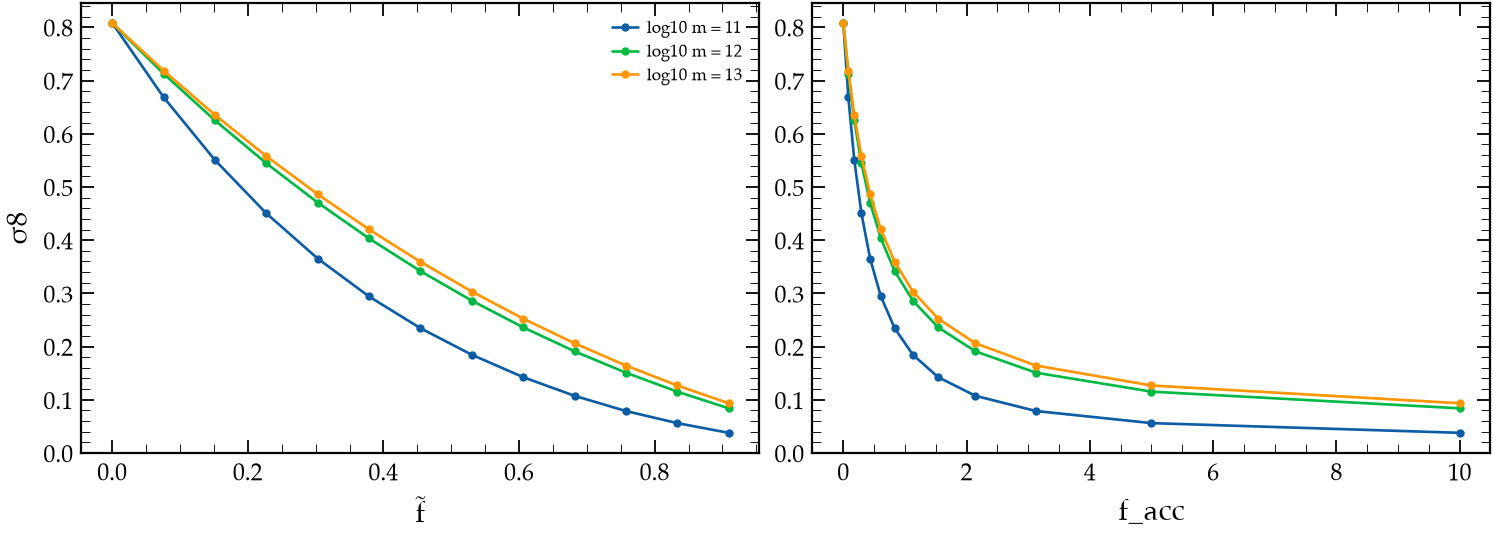

,"residual, linear in f̃","residual, linear in f_acc"
log10 m,,
11,0.174,0.508
12,0.0929,0.428
13,0.0815,0.416


In [7]:
RESP_F = np.linspace(0, 10/11, 13)
MPK = {k: v for k, v in common.items() if k != 'l_max_scalars'}
MPK.update(output='mPk', lensing='no')
grid = [(lm, ft) for lm in (11, 12, 13) for ft in RESP_F]
out = cache.many([{**MPK, 'm_acc_in_GeV': 10**lm, 'f_tilde': ft} for lm, ft in grid])
sig = {lm: np.array([o['sigma8'] for (m, _), o in zip(grid, out) if m == lm]) for lm in (11, 12, 13)}


def linear_residual(x, y):
    return np.max(np.abs(y - np.polyval(np.polyfit(x, y, 1), x)))/abs(y[-1] - y[0])


fig, axes = plt.subplots(1, 2, figsize=(10, 3.6), constrained_layout=True)
for lm, s in sig.items():
    axes[0].plot(RESP_F, s, 'o-', ms=3, label='log10 m = {:g}'.format(lm))
    axes[1].plot(RESP_F/(1 - RESP_F), s, 'o-', ms=3)
axes[0].set_xlabel('f̃')
axes[1].set_xlabel('f_acc')
axes[0].set_ylabel('σ8')
axes[0].legend(fontsize=8)
plt.show()
show(pd.DataFrame([{'log10 m': lm, 'residual, linear in f̃': linear_residual(RESP_F, s),
                    'residual, linear in f_acc': linear_residual(RESP_F/(1 - RESP_F), s)} for lm, s in sig.items()])
     .set_index('log10 m'))

## 5. The prior

A flat prior on one coordinate is not flat on the other:

- flat f̃ on [0, 1)  ⇔  p(f_acc) = (1 + f_acc)⁻² on [0, ∞);
- flat f_acc on [0, f_max]  ⇔  p(f̃) = (1 − f̃)⁻²/f_max on [0, f_max/(1 + f_max)].

Flat f̃ gives half its weight to f_acc < 1, flat f_acc on [0, 10] gives 10%. The current chains sample
flat (ω_dm,tot, f̃); relative to that, the other priors weight each sample by

| flat in | weight |
|---|---|
| (ω_dm,tot, f̃) | 1 (as sampled) |
| (ω_cdm, f̃) | (1 + f_acc)⁻¹ |
| (ω_cdm, f_acc), f_acc ≤ 10 | (1 + f_acc) |
| (ω_dm,tot, f_acc), f_acc ≤ 10 | (1 + f_acc)² |

In [8]:
BANDS = [(0, 0.01), (0.01, 0.1), (0.1, 1), (1, 5), (5, 10), (10, np.inf)]
rows = [{'f_acc band': '[{:g}, {:g})'.format(a, b), 'flat f_acc [0, 10]': (min(b, 10) - min(a, 10))/10,
         'flat f̃ [0, 1)': (1 if np.isinf(b) else b/(1 + b)) - a/(1 + a)} for a, b in BANDS]
show(pd.DataFrame(rows).set_index('f_acc band'), default='{:.4f}')

PRIORS = {'flat (omega_dm_tot, f̃)': lambda f: np.ones_like(f),
          'flat (omega_cdm, f̃)': lambda f: (1 + f)**-1.,
          'flat (omega_cdm, f_acc)': lambda f: (1 + f)*(f <= 10),
          'flat (omega_dm_tot, f_acc)': lambda f: (1 + f)**2*(f <= 10)}
rows = []
for m, s in SAMPLES.items():
    w = s['weight']
    row = {'log10 m': m}
    for label, prior in PRIORS.items():
        row['95% f̃, ' + label] = wquantile(s['f_tilde'], w*prior(s['f_acc']), 0.95)
    row['ESS ratio, flat f_acc'] = ess(w*PRIORS['flat (omega_dm_tot, f_acc)'](s['f_acc']))/ess(w)
    rows.append(row)
show(pd.DataFrame(rows).set_index('log10 m'), default='{:.3g}')

,"flat f_acc [0, 10]","flat f̃ [0, 1)"
f_acc band,,
"[0, 0.01)",0.0010,0.0099
"[0.01, 0.1)",0.0090,0.0810
"[0.1, 1)",0.0900,0.4091
"[1, 5)",0.4000,0.3333
"[5, 10)",0.5000,0.0758
"[10, inf)",0.0000,0.0909


,"95% f̃, flat (omega_dm_tot, f̃)","95% f̃, flat (omega_cdm, f̃)","95% f̃, flat (omega_cdm, f_acc)","95% f̃, flat (omega_dm_tot, f_acc)","ESS ratio, flat f_acc"
log10 m,,,,,
11.000,0.00602,0.00601,0.00604,0.00604,1
12.000,0.0121,0.0121,0.0122,0.0122,1
13.000,0.0166,0.0165,0.0166,0.0167,1
14.000,0.0257,0.0255,0.0259,0.0261,1.01
15.000,0.0719,0.0703,0.0734,0.0751,1.01
15.301,0.11,0.106,0.114,0.119,1.01
15.699,0.225,0.205,0.249,0.285,0.97


## 6. Training coverage

The first CONNECT iteration is a Latin hypercube over the prior box, so the share of its points that
lands where each posterior lives depends on the f coordinate. For each chain: the central 95% interval
of f_acc and the share of an 8000-point LHC inside it, for f_acc uniform on [0, 10] and f̃ uniform on
[0, 0.999].

In [9]:
u = qmc.LatinHypercube(d=1, seed=1).random(8000)[:, 0]
rows = []
for m, s in SAMPLES.items():
    lo, hi = (wquantile(s['f_acc'], s['weight'], q) for q in (0.025, 0.975))
    inside = lambda f: np.mean((f >= lo) & (f <= hi))
    rows.append({'log10 m': m, 'f_acc 2.5%': lo, 'f_acc 97.5%': hi, 'flat f_acc [0, 10]': inside(10*u),
                 'flat f̃ [0, 0.999]': inside(0.999*u/(1 - 0.999*u))})
coverage = pd.DataFrame(rows).set_index('log10 m')
coverage['ratio'] = coverage['flat f̃ [0, 0.999]']/coverage['flat f_acc [0, 10]']
show(coverage, default='{:.3g}')

,f_acc 2.5%,f_acc 97.5%,"flat f_acc [0, 10]","flat f̃ [0, 0.999]",ratio
log10 m,,,,,
11.000,5.82e-05,0.0073,0.00075,0.00725,9.67
12.000,0.000116,0.0148,0.0015,0.0144,9.58
13.000,0.000159,0.0202,0.002,0.0196,9.81
14.000,0.000234,0.032,0.00325,0.0307,9.46
15.000,0.000682,0.0951,0.0095,0.0861,9.07
15.301,0.001,0.155,0.0154,0.134,8.69
15.699,0.0019,0.384,0.0381,0.276,7.23
